# Análise Exploratória – Carteira de Crédito

### Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

sns.set_theme(style="whitegrid")

### Carregamento e Estrutura do dataset

In [2]:
cols = [
    'loan_amnt',
    'loan_status',
    'grade',
    'fico_range_low',
    'fico_range_high',
    'int_rate',
    'term'
]

df = pd.read_csv(
    "../data/raw/loan_default.csv",
    usecols=cols,
    low_memory=False
)

In [3]:
df.shape

(2260701, 7)

In [4]:
df.head()

,loan_amnt,term,int_rate,grade,loan_status,fico_range_low,fico_range_high
0,3600.0,36 months,13.99,C,Fully Paid,675.0,679.0
1,24700.0,36 months,11.99,C,Fully Paid,715.0,719.0
2,20000.0,60 months,10.78,B,Fully Paid,695.0,699.0
3,35000.0,60 months,14.85,C,Current,785.0,789.0
4,10400.0,60 months,22.45,F,Fully Paid,695.0,699.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 7 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term             object 
 2   int_rate         float64
 3   grade            object 
 4   loan_status      object 
 5   fico_range_low   float64
 6   fico_range_high  float64
dtypes: float64(4), object(3)
memory usage: 120.7+ MB


### Verificação de qualidade dos dados (missing / duplicates)

In [6]:
missing = (
    df.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing

loan_amnt          0.00146
term               0.00146
int_rate           0.00146
grade              0.00146
loan_status        0.00146
fico_range_low     0.00146
fico_range_high    0.00146
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(1331937)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(928764, 7)

### Filtrar contratos maduros (remover contratos ainda em andamento)

In [10]:
df = df[df['loan_status'].isin([
    'Fully Paid', 
    'Charged Off', 
    'Default'
])].copy()

In [11]:
print("shape após filtro :", df.shape)

shape após filtro : (597989, 7)


### Criar variável default

In [12]:
df.loc[:, 'default'] = df['loan_status'].isin(
    ['Charged Off', 'Default']
).astype('int8')

In [13]:
# Remover coluna que não será mais usada
df = df.drop(columns=['loan_status'])

### Criar score médio

In [14]:
df.loc[:, 'fico_score'] = (
    df['fico_range_low'] +
    df['fico_range_high']
) / 2

In [15]:
# Criar Exposure at Default (EAD)
# No contexto deste dataset, o valor do empréstimo é utilizado como proxy da exposição.

df.loc[:, 'EAD'] = df['loan_amnt']

### Limpeza da taxa de juros

In [16]:
df['int_rate'] = (
    df['int_rate']
    .astype(str)
    .str.replace('%','')
    .astype(float)
)

### Estrutura da Carteira

In [17]:
print("Número de contratos:", len(df))
print("Exposição total da carteira:", df['EAD'].sum())
print("Ticket médio:", df['EAD'].mean())
print("Score mínimo:", df['fico_score'].min())
print("Score máximo:", df['fico_score'].max())

Número de contratos: 597989
Exposição total da carteira: 8897981225.0
Ticket médio: 14879.840975335666
Score mínimo: 627.0
Score máximo: 847.5


### Distribuição da Exposição (EAD)

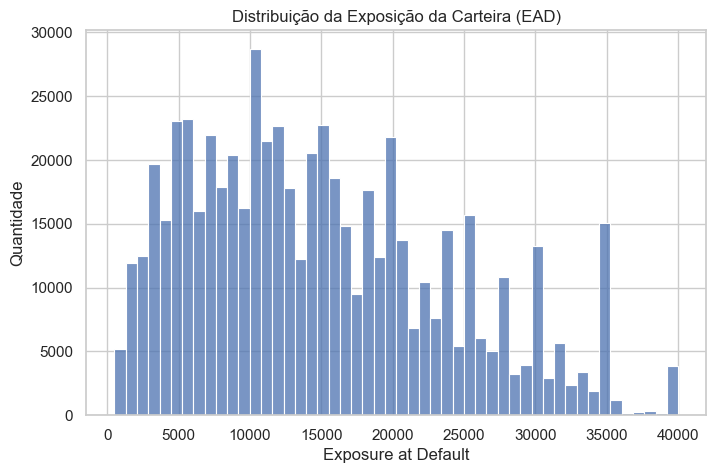

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['EAD'], bins=50)

plt.title("Distribuição da Exposição da Carteira (EAD)")
plt.xlabel("Exposure at Default")
plt.ylabel("Quantidade")

plt.show()

### Concentração da Exposição da Carteira

In [19]:
ead_sorted = df.sort_values('EAD', ascending=False)

ead_sorted['cum_exposure_share'] = (
    ead_sorted['EAD'].cumsum() /
    ead_sorted['EAD'].sum()
)

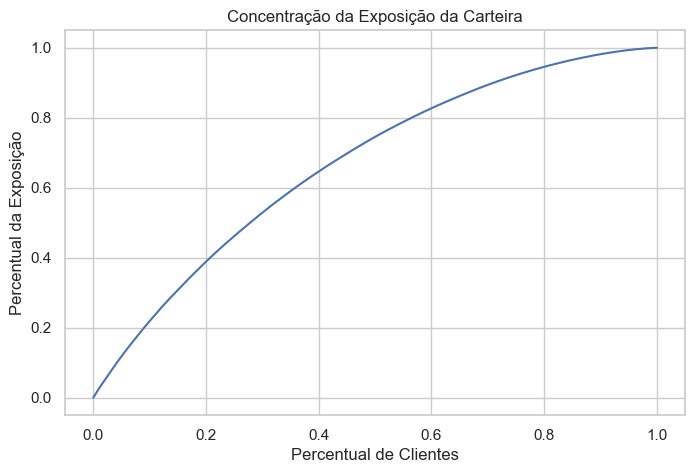

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    np.linspace(0,1,len(ead_sorted)),
    ead_sorted['cum_exposure_share']
)

plt.title("Concentração da Exposição da Carteira")
plt.xlabel("Percentual de Clientes")
plt.ylabel("Percentual da Exposição")

plt.show()

### Distribuição Score

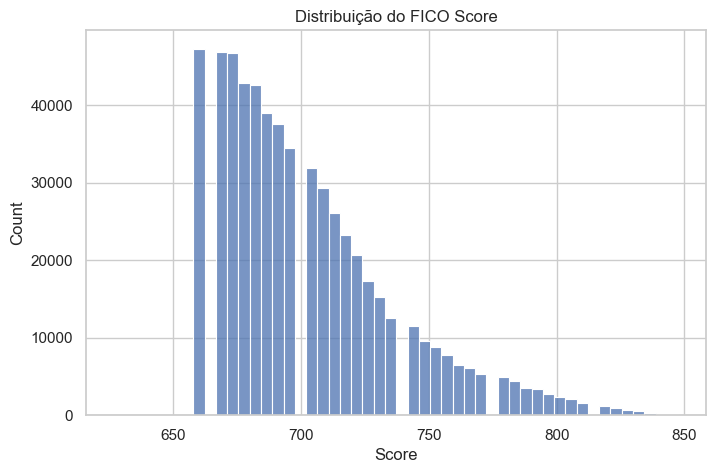

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['fico_score'], bins=50)

plt.title("Distribuição do FICO Score")
plt.xlabel("Score")
plt.show()

### Distribuição grade

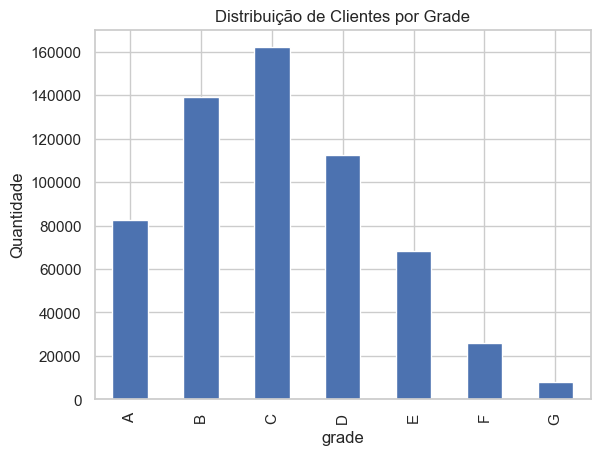

In [22]:
df['grade'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribuição de Clientes por Grade")
plt.ylabel("Quantidade")
plt.show()

### Distribuição do Prazo do Empréstimo (Term)

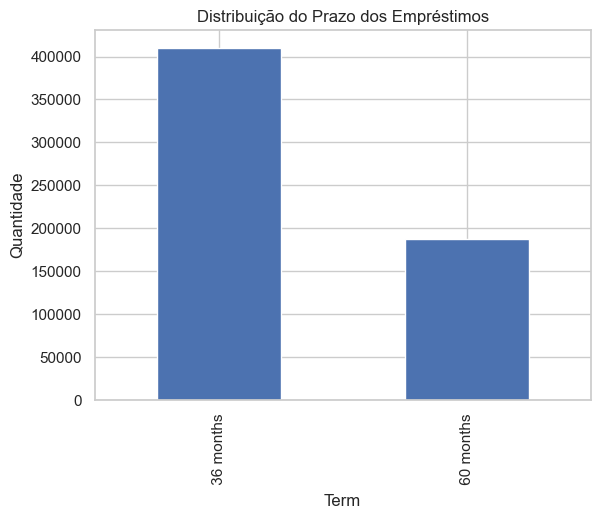

In [23]:
df['term'].value_counts().plot(kind='bar')

plt.title("Distribuição do Prazo dos Empréstimos")
plt.xlabel("Term")
plt.ylabel("Quantidade")

plt.show()

In [24]:
# Default por prazo
term_default = (
    df.groupby('term')
    .agg(
        pd=('default','mean'),
        volume=('default','count')
    )
)

term_default

,pd,volume
term,,
36 months,0.238016,410364
60 months,0.362532,187625


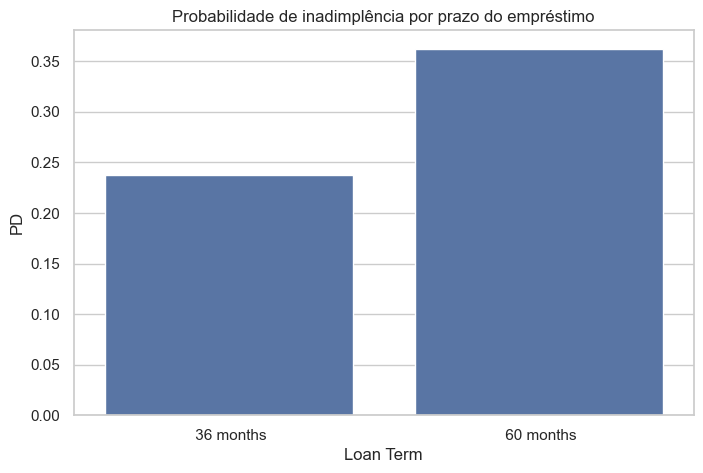

In [25]:
# %%
plt.figure(figsize=(8,5))

sns.barplot(
    x=term_default.index,
    y=term_default['pd']
)

plt.title("Probabilidade de inadimplência por prazo do empréstimo")
plt.ylabel("PD")
plt.xlabel("Loan Term")

plt.show()

### Taxa média de default

In [26]:
default_rate = df['default'].mean()
print(f"Taxa média de default da carteira: {default_rate:.2%}")

Taxa média de default da carteira: 27.71%


### PD por grade

In [27]:
# Calcular PD por grade

pd_grade = (
    df.groupby('grade')
    .agg(
        pd=('default','mean'),
        volume=('default','count')
    )
    .sort_index()
)

pd_grade

,pd,volume
grade,,
A,0.122348,82339
B,0.207949,139068
C,0.282907,162000
D,0.336472,112241
E,0.396794,68320
F,0.459422,25950
G,0.504522,8071


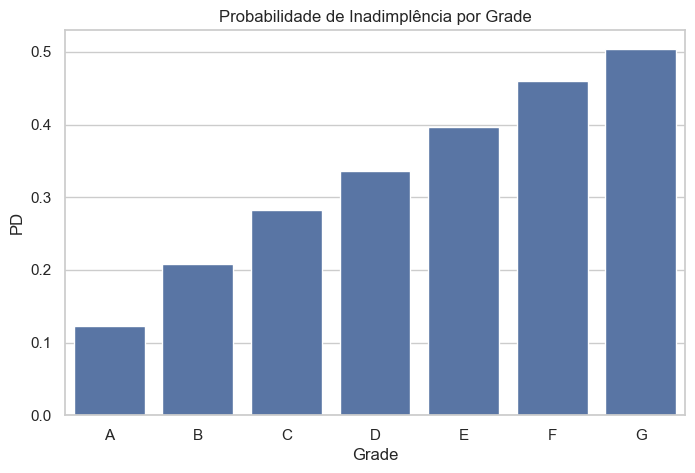

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=pd_grade.index,
    y=pd_grade['pd']
)

plt.title("Probabilidade de Inadimplência por Grade")
plt.ylabel("PD")
plt.xlabel("Grade")

plt.show()

### Exposição da Carteira por Grade

In [29]:
ead_grade = (
    df.groupby('grade')
    .agg(
        exposure=('EAD','sum'),
        contracts=('EAD','count')
    )
    .sort_index()
)

ead_grade['share_exposure'] = (
    ead_grade['exposure'] /
    ead_grade['exposure'].sum()
)

ead_grade

,exposure,contracts,share_exposure
grade,,,
A,1.107740e+09,82339,0.124493
B,1.958903e+09,139068,0.220151
C,2.384536e+09,162000,0.267986
D,1.683910e+09,112241,0.189246
E,1.132994e+09,68320,0.127332
F,4.701584e+08,25950,0.052839
G,1.597390e+08,8071,0.017952


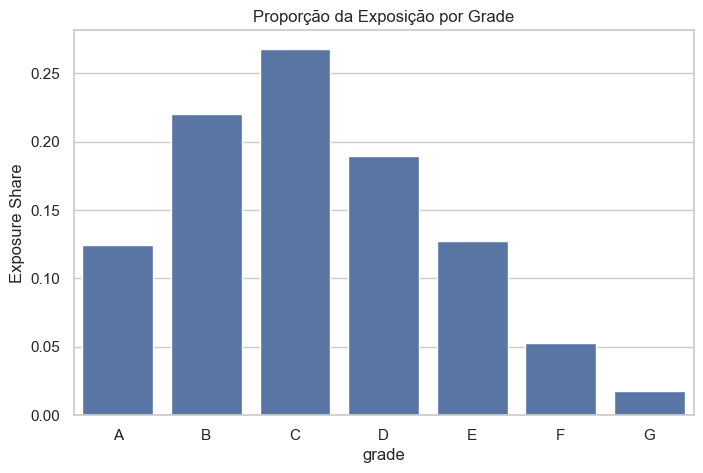

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=ead_grade.index,
    y=ead_grade['share_exposure']
)

plt.title("Proporção da Exposição por Grade")
plt.ylabel("Exposure Share")

plt.show()

### Exposição vs default

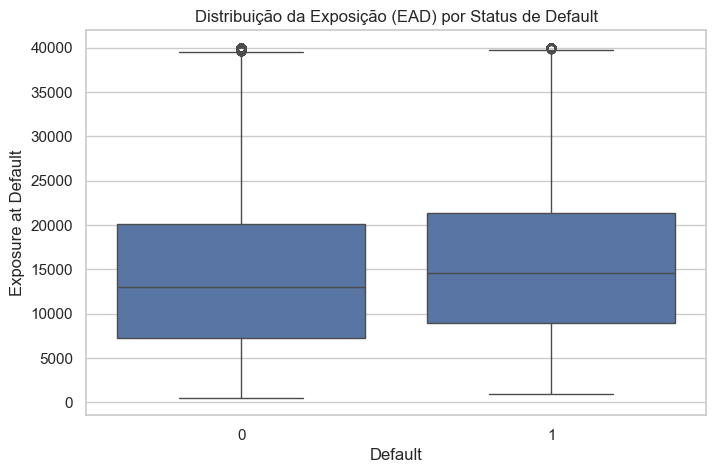

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='default',
    y='EAD',
    data=df
)

plt.title("Distribuição da Exposição (EAD) por Status de Default")
plt.xlabel("Default")
plt.ylabel("Exposure at Default")
plt.show()

### Boxplot score vs default


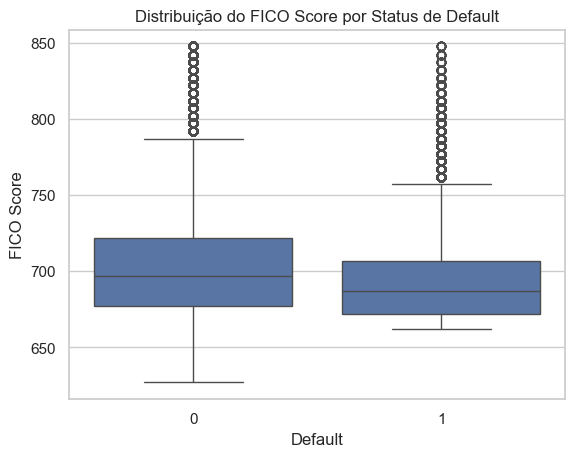

In [32]:
sns.boxplot(x='default', y='fico_score', data=df)

plt.title("Distribuição do FICO Score por Status de Default")
plt.xlabel("Default")
plt.ylabel("FICO Score")

plt.show()

### Estatísticas agregadas por default

In [33]:
display(df.groupby('default')['fico_score'].describe())

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,432296.0,705.367592,35.932585,627.0,677.0,697.0,722.0,847.5
1,165693.0,694.089539,28.592057,662.0,672.0,687.0,707.0,847.5


### Risk Curve (Score vs Default)

In [34]:
score_bins = pd.qcut(df['fico_score'], q=10)

risk_curve = (
    df
    .groupby(score_bins, observed=False)
    .agg(
        pd=('default','mean'),
        volume=('default','count'),
        avg_score=('fico_score','mean')
    )
    .reset_index()
)

risk_curve

,fico_score,pd,volume,avg_score
0,"(626.999, 667.0]",0.349254,94112,664.487621
1,"(667.0, 672.0]",0.336269,46662,672.000000
2,"(672.0, 677.0]",0.329474,42841,677.000000
3,"(677.0, 687.0]",0.312861,81477,684.387606
4,"(687.0, 692.0]",0.300370,37517,692.000000
5,"(692.0, 702.0]",0.284378,66366,699.404092
6,"(702.0, 712.0]",0.261293,55367,709.359709
7,"(712.0, 727.0]",0.233905,61277,721.513847
8,"(727.0, 752.0]",0.195252,57797,740.629773
9,"(752.0, 847.5]",0.133766,54573,780.662956


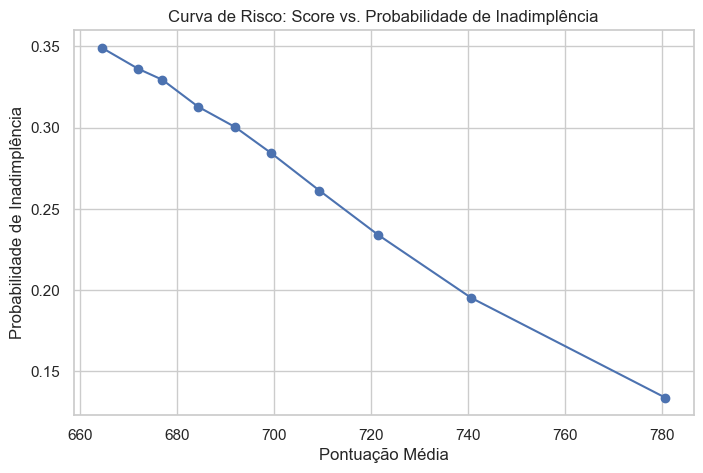

In [35]:
# %%
plt.figure(figsize=(8,5))

plt.plot(
    risk_curve['avg_score'],
    risk_curve['pd'],
    marker='o'
)

plt.title("Curva de Risco: Score vs. Probabilidade de Inadimplência")
plt.xlabel("Pontuação Média")
plt.ylabel("Probabilidade de Inadimplência")

plt.show()

### Correlação

In [36]:
corr, _ = pointbiserialr(df['default'], df['fico_score'])
print(f"Correlação default vs score: {corr:.3f}")

Correlação default vs score: -0.147


### Matriz de correlação

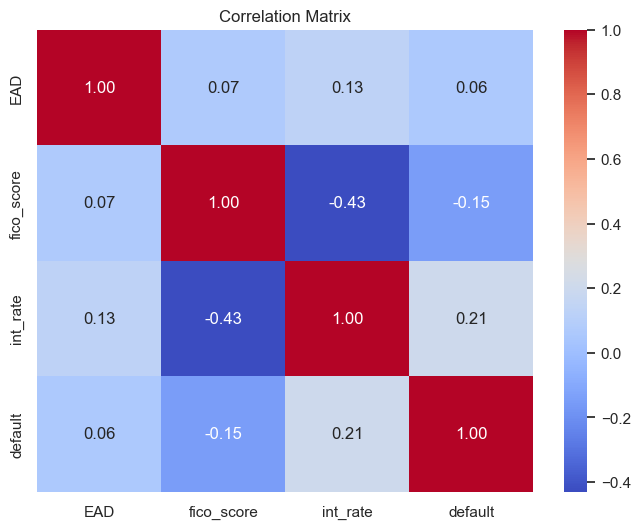

In [37]:
plt.figure(figsize=(8,6))

corr_matrix = df[['EAD','fico_score','int_rate','default']].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Salvamento do Dataset Processado

Após a etapa de análise exploratória e preparação inicial dos dados, salvamos o dataset processado contendo apenas as variáveis relevantes para as etapas seguintes do projeto.

Esse dataset será utilizado na construção da carteira de crédito e nas simulações de risco.

In [38]:
df.to_parquet("../data/processed/credit_risk_clean.parquet",
              index=False)

## Conclusões da Análise Exploratória

A análise exploratória teve como objetivo compreender a estrutura da carteira de crédito e identificar fatores associados ao risco de inadimplência.

A carteira analisada possui aproximadamente **598 mil contratos**, com **exposição total superior a 8,8 bilhões**, evidenciando um portfólio com volume relevante de crédito e heterogeneidade significativa entre os tomadores.

Os principais achados da análise foram:

* A carteira apresenta **taxa média de default de aproximadamente 27%**, indicando um portfólio com nível de risco moderado a elevado, o que é consistente com carteiras de crédito **não garantido (unsecured lending)**.

* A variável **grade** demonstra forte capacidade de segmentação de risco, com aumento monotônico da taxa de inadimplência de aproximadamente **6% para clientes grade A até cerca de 50% para clientes grade G**, evidenciando que a classificação de crédito captura adequadamente o perfil de risco dos tomadores.

* O **FICO Score** apresenta relação inversa com inadimplência, com correlação de aproximadamente **-0.15** com a variável de default. Esse resultado indica que clientes com maior score tendem a apresentar menor probabilidade de inadimplência.

* Apesar dessa tendência clara, observa-se **sobreposição entre as distribuições de score de clientes adimplentes e inadimplentes**, reforçando que o risco de crédito é **probabilístico e não determinístico**, sendo influenciado por múltiplos fatores além do score.

De forma geral, os resultados indicam que a carteira apresenta **heterogeneidade significativa de risco**, justificando a segmentação dos clientes na modelagem da **Probabilidade de Default (PD)**.

Nas próximas etapas do projeto será construída uma **estrutura de modelagem de risco da carteira**, incorporando os componentes fundamentais do risco de crédito — **Probabilidade de Default (PD), Loss Given Default (LGD) e Exposure at Default (EAD)** — para posteriormente realizar **simulações de perda utilizando Monte Carlo**, permitindo estimar métricas de risco como **Expected Loss e Value at Risk (VaR)** da carteira.

